<a href="https://colab.research.google.com/github/DebosmitaSarkar2003/DataFest-Hackathon-2025-Loyala/blob/main/DataFeast_Loyola.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
SVH DataFest 2026 — Complete Mental Health Analysis
====================================================
Run this as ONE single cell in Google Colab.
Make sure encounters.csv is uploaded to Google Drive first.

Before running:
1. Upload encounters.csv to Google Drive
2. Change ENCOUNTERS_PATH if needed
"""

# ── Imports ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# ── Config ────────────────────────────────────────────────────
CONTENT_DIR     = "/content/"
ENCOUNTERS_PATH = "/drive/MyDrive/encounters.csv"

# ════════════════════════════════════════════════════════════════
# STEP 0 — MOUNT GOOGLE DRIVE
# ════════════════════════════════════════════════════════════════
print("=" * 60)
print("STEP 0: Mounting Google Drive...")
print("=" * 60)

from google.colab import drive
drive.mount("/drive", force_remount=False)

import os
size = os.path.getsize(ENCOUNTERS_PATH)
print(f"  encounters.csv size: {size/1e9:.2f} GB")
if size < 1e9:
    print("  WARNING: File too small — should be ~1.5 GB!")
    print("  Make sure full file uploaded to Drive.")
else:
    print("  File size looks good!")

# ════════════════════════════════════════════════════════════════
# STEP 1 — LOAD SMALL FILES
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 1: Loading small files...")
print("=" * 60)

def load(path, parse_dates=None):
    df = pd.read_csv(
        path,
        engine       = "python",
        on_bad_lines = "skip",
        encoding     = "latin1",
        parse_dates  = parse_dates,
    )
    print(f"  {path.split('/')[-1]}: {len(df):,} rows")
    return df

patients    = load(CONTENT_DIR + "patients.csv")
diagnosis   = load(CONTENT_DIR + "diagnosis.csv")
departments = load(CONTENT_DIR + "departments.csv")
social      = load(CONTENT_DIR + "social_determinants.csv")

# Fix types
social["EncounterKey"]       = pd.to_numeric(social["EncounterKey"],       errors="coerce").astype("Int64")
social["PatientDurableKey"]  = pd.to_numeric(social["PatientDurableKey"],  errors="coerce").astype("Int64")
diagnosis["DiagnosisKey"]    = pd.to_numeric(diagnosis["DiagnosisKey"],    errors="coerce").astype("Int64")
patients["DurableKey"]       = pd.to_numeric(patients["DurableKey"],       errors="coerce").astype("Int64")
departments["DepartmentKey"] = pd.to_numeric(departments["DepartmentKey"], errors="coerce").astype("Int64")

print("  All small files loaded!")

# ════════════════════════════════════════════════════════════════
# STEP 2 — IDENTIFY TARGET KEYS BEFORE LOADING ENCOUNTERS
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 2: Identifying target patients...")
print("=" * 60)

# Edinburgh Depression Scale — score >= 10 = positive screen
dep = social[
    social["DisplayName"].str.contains("Edinburgh", na=False)
].copy()
dep["Score"] = pd.to_numeric(dep["AnswerText"], errors="coerce")
dep_scores   = dep.groupby("PatientDurableKey")["Score"].max().reset_index()

pos = dep[dep["Score"] >= 10][
    ["PatientDurableKey", "EncounterKey"]
].drop_duplicates()
pos["PatientDurableKey"] = pos["PatientDurableKey"].astype("Int64")
pos["EncounterKey"]      = pos["EncounterKey"].astype("Int64")

target_enc_keys = set(pos["EncounterKey"].dropna().astype(int))
target_pat_keys = set(pos["PatientDurableKey"].dropna().astype(int))

# Behavioral health dept keys
psych_depts = set(departments[
    departments["DepartmentSpecialty"].str.contains(
        "Psychiatry|Behavioral|Mental|Psychology|Counsel|Substance",
        na=False, case=False)
]["DepartmentKey"].dropna().astype(int))

# Mental health F-code diagnosis keys
mh_keys = set(diagnosis[
    diagnosis["DiagnosisValue"].str.startswith("F", na=False)
]["DiagnosisKey"].dropna().astype(int))

# Score distribution
total_edinburgh = len(dep)
score_lt10  = (dep["Score"] < 10).sum()
score_gte10 = (dep["Score"] >= 10).sum()

print(f"  Total Edinburgh screenings  : {total_edinburgh:,}")
print(f"  Score < 10  (no depression) : {score_lt10:,}")
print(f"  Score >= 10 (positive)      : {score_gte10:,}")
print(f"  Unique positive patients    : {len(target_pat_keys):,}")
print(f"  Psych department keys       : {len(psych_depts):,}")
print(f"  MH diagnosis keys           : {len(mh_keys):,}")

# ════════════════════════════════════════════════════════════════
# STEP 3 — LOAD ENCOUNTERS IN CHUNKS (RAM-SAFE)
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 3: Loading encounters in chunks (3-5 mins)...")
print("=" * 60)

screen_rows, bh_rows = [], []
chunks_done = 0

try:
    reader = pd.read_csv(
        ENCOUNTERS_PATH,
        engine       = "python",
        on_bad_lines = "skip",
        encoding     = "latin1",
        usecols      = ["EncounterKey", "PatientDurableKey", "Date",
                        "DepartmentKey", "PrimaryDiagnosisKey"],
        parse_dates  = ["Date"],
        dtype        = {
            "EncounterKey"        : "float32",
            "PatientDurableKey"   : "float32",
            "DepartmentKey"       : "float32",
            "PrimaryDiagnosisKey" : "float32",
        },
        chunksize = 150000,
    )

    for chunk in reader:
        chunks_done += 1
        chunk = chunk.dropna(subset=["EncounterKey", "PatientDurableKey"])
        chunk["EncounterKey"]        = chunk["EncounterKey"].astype(int)
        chunk["PatientDurableKey"]   = chunk["PatientDurableKey"].astype(int)
        chunk["DepartmentKey"]       = pd.to_numeric(chunk["DepartmentKey"],       errors="coerce")
        chunk["PrimaryDiagnosisKey"] = pd.to_numeric(chunk["PrimaryDiagnosisKey"], errors="coerce")

        # Screen encounters
        s = chunk[chunk["EncounterKey"].isin(target_enc_keys)][
            ["EncounterKey", "PatientDurableKey", "Date"]
        ]
        if len(s) > 0:
            screen_rows.append(s)

        # BH visits
        bh = chunk[
            chunk["DepartmentKey"].isin(psych_depts) |
            chunk["PrimaryDiagnosisKey"].isin(mh_keys)
        ][["PatientDurableKey", "Date"]]
        if len(bh) > 0:
            bh_rows.append(bh)

        if chunks_done % 10 == 0:
            yr = chunk["Date"].dt.year.mode()[0] if len(chunk) > 0 else "?"
            print(f"  Chunk {chunks_done:>2} | year ~{yr} | "
                  f"screen: {sum(len(x) for x in screen_rows):,} | "
                  f"bh: {sum(len(x) for x in bh_rows):,}")

except Exception as e:
    print(f"  Stopped at chunk {chunks_done}: {e}")

print(f"\n  Done! {chunks_done} chunks processed")

# Combine
screen_df = pd.concat(screen_rows, ignore_index=True) if screen_rows \
            else pd.DataFrame(columns=["EncounterKey","PatientDurableKey","Date"])
bh_actual = pd.concat(bh_rows, ignore_index=True).drop_duplicates() if bh_rows \
            else pd.DataFrame(columns=["PatientDurableKey","Date"])

screen_df["EncounterKey"]      = screen_df["EncounterKey"].astype("Int64")
screen_df["PatientDurableKey"] = screen_df["PatientDurableKey"].astype("Int64")

print(f"  Screen encounters matched : {len(screen_df):,}")
print(f"  BH encounters found       : {len(bh_actual):,}")
print(f"  Unique BH patients        : {bh_actual['PatientDurableKey'].nunique():,}")

# ════════════════════════════════════════════════════════════════
# STEP 4 — BUILD JOURNEY TABLE
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 4: Building journey table...")
print("=" * 60)

# Match screen dates
screen_with_date = pos.merge(
    screen_df[["EncounterKey", "PatientDurableKey", "Date"]],
    on=["EncounterKey", "PatientDurableKey"],
    how="left"
)
matched = screen_with_date["Date"].notna().sum()
print(f"  Screen dates matched    : {matched:,} / {len(screen_with_date):,}")

# Proxy date for unmatched
screen_with_date["Date"] = screen_with_date["Date"].fillna(
    pd.Timestamp("2024-01-01")
)

# Earliest screen per patient
screen_final = (
    screen_with_date.sort_values("Date")
    .groupby("PatientDurableKey").first()
    .reset_index()
    .rename(columns={"Date": "ScreenDate", "EncounterKey": "ScreenKey"})
)
screen_final = screen_final.merge(dep_scores, on="PatientDurableKey", how="left")

# First BH visit per patient
bh_actual["PatientDurableKey"] = bh_actual["PatientDurableKey"].astype("Int64")
first_bh = (
    bh_actual.groupby("PatientDurableKey")["Date"]
    .min().reset_index()
    .rename(columns={"Date": "FirstBHDate"})
)
first_bh["PatientDurableKey"] = first_bh["PatientDurableKey"].astype("Int64")

# Build journey
journey = screen_final.merge(first_bh, on="PatientDurableKey", how="left")
journey["GotCareAfter"] = journey["FirstBHDate"] > journey["ScreenDate"]
journey["DaysToCare"]   = (journey["FirstBHDate"] - journey["ScreenDate"]).dt.days
journey.loc[journey["DaysToCare"] <= 0, "DaysToCare"]   = np.nan
journey.loc[journey["DaysToCare"] <= 0, "GotCareAfter"] = False
journey["Care30"] = journey["DaysToCare"].notna() & (journey["DaysToCare"] <= 30)
journey["Care90"] = journey["DaysToCare"].notna() & (journey["DaysToCare"] <= 90)

# Severity
def severity(s):
    if pd.isna(s):  return "Unknown"
    elif s < 10:    return "Minimal"
    elif s < 14:    return "Mild"
    elif s < 20:    return "Moderate"
    else:           return "Severe"
journey["Severity"] = journey["Score"].apply(severity)

# Age
patients["DurableKey"] = patients["DurableKey"].astype("Int64")
journey = journey.merge(
    patients[["DurableKey", "PatientBirthYearBin", "FirstRace"]],
    left_on="PatientDurableKey", right_on="DurableKey", how="left"
)
journey["ApproxAge"] = 2025 - journey["PatientBirthYearBin"]

def age_grp(a):
    if pd.isna(a):  return "Unknown"
    elif a < 18:    return "Under 18"
    elif a < 35:    return "18–34"
    elif a < 50:    return "35–49"
    elif a < 65:    return "50–64"
    else:           return "65+"
journey["AgeGroup"] = journey["ApproxAge"].apply(age_grp)

# Transport barrier
t_rows = social[
    social["Domain"].str.lower().str.contains("transport", na=False) |
    social["DisplayName"].str.lower().str.contains("transport", na=False)
].copy()
NEGATIVE_T = ["no", "never", "always", "usually",
              "not a problem", "not difficult", "unknown"]
def is_barrier(a):
    if pd.isna(a): return False
    a = str(a).lower().strip()
    return not any(neg in a for neg in NEGATIVE_T) and len(a) > 0
t_rows["IsBarrier"] = t_rows["AnswerText"].apply(is_barrier)
flagged = set(t_rows[t_rows["IsBarrier"]]["PatientDurableKey"].dropna().astype(int))
journey["HasBarrier"] = journey["PatientDurableKey"].isin(flagged)

print(f"  Journey rows built      : {len(journey):,}")
print(f"  With transport barrier  : {journey['HasBarrier'].sum():,}")

# ════════════════════════════════════════════════════════════════
# STEP 5 — COMPUTE ALL RESULTS
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 5: Computing results...")
print("=" * 60)

total    = len(journey)
got_any  = int(journey["GotCareAfter"].sum())
got_30   = int(journey["Care30"].sum())
got_90   = int(journey["Care90"].sum())
never    = total - got_any
med_wait = journey["DaysToCare"].median()
t_no     = journey[~journey["HasBarrier"]]["GotCareAfter"].mean() * 100
t_yes    = journey[ journey["HasBarrier"]]["GotCareAfter"].mean() * 100
u18      = journey[journey["AgeGroup"] == "Under 18"]

print(f"  Total screened positive     : {total:,}")
print(f"  Got ANY BH care after       : {got_any:,}  ({got_any/total*100:.1f}%)")
print(f"  Care within 30 days         : {got_30:,}  ({got_30/total*100:.1f}%)")
print(f"  Care within 90 days         : {got_90:,}  ({got_90/total*100:.1f}%)")
print(f"  NEVER got BH care           : {never:,}  ({never/total*100:.1f}%)")
print(f"  Median wait (days)          : {med_wait:.0f}")
print(f"  No barrier care rate        : {t_no:.1f}%")
print(f"  Has barrier care rate       : {t_yes:.1f}%")
print(f"  Children under 18 care rate : {u18['GotCareAfter'].mean()*100:.1f}%")

print("\n  By severity:")
for sev in ["Mild", "Moderate", "Severe"]:
    sub = journey[journey["Severity"] == sev]
    if len(sub) > 0:
        print(f"    {sev:<12} n={len(sub):>4}  care rate: {sub['GotCareAfter'].mean()*100:.1f}%")

# ════════════════════════════════════════════════════════════════
# STEP 6 — VERIFICATION TABLE
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 6: VERIFICATION — Slide numbers vs actual data")
print("=" * 60)

mild_n     = (journey["Severity"] == "Mild").sum()
mod_n      = (journey["Severity"] == "Moderate").sum()
sev_n      = (journey["Severity"] == "Severe").sum()
mild_care  = journey[journey["Severity"]=="Mild"]["GotCareAfter"].mean()*100
mod_care   = journey[journey["Severity"]=="Moderate"]["GotCareAfter"].mean()*100
sev_care   = journey[journey["Severity"]=="Severe"]["GotCareAfter"].mean()*100

checks = [
    ("Total screened positive",      "1,048",  total,               1048, 2),
    ("Mild patients (10-13)",        "619",    mild_n,               619, 2),
    ("Moderate patients (14-19)",    "328",    mod_n,                328, 2),
    ("Severe patients (20+)",        "101",    sev_n,                101, 2),
    ("Never got care %",             "86%",    never/total*100,       86, 3),
    ("Got any care %",               "14.4%",  got_any/total*100,   14.4, 3),
    ("Care within 30 days %",        "0.4%",   got_30/total*100,    0.4,  1),
    ("Care within 90 days %",        "1.4%",   got_90/total*100,    1.4,  1),
    ("Median wait days",             "417d",   med_wait,             417, 30),
    ("Children under 18 care %",     "0.0%",   u18["GotCareAfter"].mean()*100, 0, 2),
    ("No transport barrier %",       "13.7%",  t_no,                13.7, 4),
    ("Has transport barrier %",      "21.2%",  t_yes,               21.2, 4),
    ("Mild care rate",               "12.1%",  mild_care,           12.1, 4),
    ("Moderate care rate",           "16.8%",  mod_care,            16.8, 4),
    ("Severe care rate",             "20.8%",  sev_care,            20.8, 4),
]

print(f"\n  {'Metric':<36} {'Slide':>8}  {'Actual':>8}  {'Status':>8}")
print("  " + "-" * 65)

all_good = True
for label, slide, actual, expected, tol in checks:
    ok = abs(actual - expected) <= tol
    if not ok: all_good = False
    status = "✓ OK" if ok else "✗ CHECK"
    print(f"  {label:<36} {slide:>8}  {actual:>7.1f}   {status}")

print("\n" + "=" * 60)
if all_good:
    print("ALL ✓  —  Every number verified! Safe to present.")
else:
    print("Some numbers differ — review ✗ rows before presenting.")
print("=" * 60)

# ════════════════════════════════════════════════════════════════
# STEP 7 — CHARTS
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 7: Making charts → svh_mental_health.png")
print("=" * 60)

CORAL    = "#D85A30"
TEAL     = "#1D9E75"
PURPLE   = "#7F77DD"
AMBER    = "#BA7517"
GRAY     = "#888780"
DARK_RED = "#8B0000"

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "Mental Health Care After Depression Screening — SVH DataFest 2026",
    fontsize=14, fontweight="bold"
)

# Chart 1 — Donut
ax = axes[0, 0]
gp  = got_any / total * 100
np_ = never   / total * 100
ax.pie([gp, np_], colors=[TEAL, CORAL],
       startangle=90, wedgeprops=dict(width=0.55))
ax.text(0,  0.15, f"{np_:.0f}%",      ha="center",
        fontsize=28, fontweight="bold", color=CORAL)
ax.text(0, -0.25, "never got care",   ha="center",
        fontsize=11, color=CORAL)
ax.set_title("Did screened patients get\nbehavioral health care?",
             fontweight="bold")
ax.legend(handles=[
    mpatches.Patch(color=TEAL,  label=f"Got care  {gp:.1f}%"),
    mpatches.Patch(color=CORAL, label=f"Never got care  {np_:.1f}%")],
    loc="lower center", bbox_to_anchor=(0.5, -0.08), fontsize=9)

# Chart 2 — Funnel
ax = axes[0, 1]
vals   = [total, got_90, got_30, got_any]
labels = ["Screened\npositive", "Care\nwithin 90d",
          "Care\nwithin 30d", "Any care\never"]
bars   = ax.bar(labels, vals,
                color=[GRAY, PURPLE, TEAL, AMBER],
                edgecolor="white", width=0.6)
ax.set_title("Care funnel — how many got help?", fontweight="bold")
ax.set_ylabel("Number of patients")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:.0f}"))
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(vals) * 0.01,
            f"{val/total*100:.1f}%",
            ha="center", fontsize=10, fontweight="bold")

# Chart 3 — Severity
ax = axes[0, 2]
sev_labels = ["Mild\n(10-13)", "Moderate\n(14-19)", "Severe\n(20+)"]
sev_rates  = [mild_care, mod_care, sev_care]
sev_colors = [AMBER, CORAL, DARK_RED]
bars = ax.bar(sev_labels, sev_rates, color=sev_colors,
              edgecolor="white", width=0.5)
ax.set_title("Care rate by depression severity", fontweight="bold")
ax.set_ylabel("% who ever got BH care")
ax.set_ylim(0, max(sev_rates) * 1.4)
for bar, val in zip(bars, sev_rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center",
            fontsize=11, fontweight="bold")

# Chart 4 — Transport
ax = axes[1, 0]
bars = ax.bar(["No barrier", "Has barrier"], [t_no, t_yes],
              color=[TEAL, CORAL], edgecolor="white", width=0.5)
ax.set_title("Care rate vs transport barrier", fontweight="bold")
ax.set_ylabel("% who ever got BH care")
ax.set_ylim(0, max(t_no, t_yes) * 1.4 if max(t_no, t_yes) > 0 else 10)
for bar, val in zip(bars, [t_no, t_yes]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center",
            fontsize=13, fontweight="bold")

# Chart 5 — Age
ax = axes[1, 1]
age_order = ["Under 18", "18–34", "35–49", "50–64", "65+"]
age_rates, age_labels = [], []
for g in age_order:
    sub = journey[journey["AgeGroup"] == g]
    if len(sub) > 5:
        age_rates.append(sub["GotCareAfter"].mean() * 100)
        age_labels.append(g)
if age_rates:
    bars = ax.bar(age_labels, age_rates, color=PURPLE,
                  edgecolor="white", width=0.6)
    ax.set_title("Care rate by age group", fontweight="bold")
    ax.set_ylabel("% who ever got BH care")
    ax.set_ylim(0, max(age_rates) * 1.4)
    for bar, val in zip(bars, age_rates):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f"{val:.1f}%", ha="center",
                fontsize=10, fontweight="bold")

# Chart 6 — Wait time histogram
ax = axes[1, 2]
days_data = journey["DaysToCare"].dropna().clip(upper=730)
if len(days_data) > 0:
    ax.hist(days_data, bins=30, color=PURPLE,
            edgecolor="white", linewidth=0.3)
    ax.axvline(30,  color=CORAL, linestyle="--",
               linewidth=2, label="30 days")
    ax.axvline(90,  color=AMBER, linestyle="--",
               linewidth=2, label="90 days")
    ax.axvline(days_data.median(), color=TEAL, linestyle="-",
               linewidth=2.5,
               label=f"Median ({days_data.median():.0f}d)")
    ax.set_title("How long did patients wait?\n(those who got care)",
                 fontweight="bold")
    ax.set_xlabel("Days from screening to first BH visit")
    ax.set_ylabel("Number of patients")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("svh_mental_health.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: svh_mental_health.png")

# ════════════════════════════════════════════════════════════════
# STEP 8 — YOUR SLIDE NUMBERS
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 8: YOUR STORY — COPY INTO SLIDES")
print("=" * 60)
print(f"""
  ┌──────────────────────────────────────────────────────────┐
  │  SLIDE 1 — Hook                                          │
  │  "They Asked For Help. Did Anyone Listen?"               │
  │                                                          │
  │  SLIDE 2 — The data                                      │
  │  "7.6M encounters · 947K patients · 4 years · 7 files"  │
  │                                                          │
  │  SLIDE 3 — The tool                                      │
  │  "Edinburgh Depression Scale — score >= 10 = depressed"  │
  │  "{total_edinburgh:,} screenings → {total:,} patients flagged"              │
  │  "Mild: {mild_n} · Moderate: {mod_n} · Severe: {sev_n}"              │
  │                                                          │
  │  SLIDE 4 — The finding                                   │
  │  "{never/total*100:.0f}% NEVER got mental health care"               │
  │  "Only {got_any/total*100:.1f}% ever got behavioral health care"     │
  │  "Only {got_30/total*100:.1f}% got care within 30 days"             │
  │  "Median wait: {med_wait:.0f} days — over a year"               │
  │                                                          │
  │  SLIDE 5 — Charts (embed svh_mental_health.png)          │
  │                                                          │
  │  SLIDE 6 — Who gets left behind                          │
  │  "Children under 18: {u18['GotCareAfter'].mean()*100:.0f}% got care"              │
  │  "Severe depression: {sev_care:.1f}% got care"                │
  │  "No barrier: {t_no:.1f}% · Has barrier: {t_yes:.1f}%"         │
  │                                                          │
  │  SLIDE 7 — Methodology (how we found this)               │
  │  Edinburgh Scale → filter score >= 10 → match BH visits  │
  │                                                          │
  │  SLIDE 8 — Recommendation                                │
  │  "The screening works. The referral is broken."           │
  │  "Auto-book psychiatry for every score >= 10"             │
  │  "Prioritize children and severe cases immediately"       │
  └──────────────────────────────────────────────────────────┘
""")
print("DONE!")
print("Charts saved as: svh_mental_health.png")
print("Download it and use in your presentation slides.")

STEP 0: Mounting Google Drive...
Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
  encounters.csv size: 1.47 GB
  File size looks good!

STEP 1: Loading small files...
  patients.csv: 947,685 rows
  diagnosis.csv: 1,531,262 rows
  departments.csv: 11,597 rows
  social_determinants.csv: 2,948,464 rows
  All small files loaded!

STEP 2: Identifying target patients...
  Total Edinburgh screenings  : 15,542
  Score < 10  (no depression) : 13,714
  Score >= 10 (positive)      : 1,828
  Unique positive patients    : 1,048
  Psych department keys       : 96
  MH diagnosis keys           : 25,858

STEP 3: Loading encounters in chunks (3-5 mins)...
  Chunk 10 | year ~2022 | screen: 0 | bh: 25,323
  Chunk 20 | year ~2023 | screen: 0 | bh: 49,961
  Chunk 30 | year ~2024 | screen: 0 | bh: 72,909
  Chunk 40 | year ~2025 | screen: 308 | bh: 97,230
  Chunk 50 | year ~2025 | screen: 902 | bh: 119,819

  Done! 52 chunks processed
  Screen

KeyError: 'PatientDurableKey'

In [ ]:
# Fix — run this in a new cell immediately after the previous one
# Everything loaded fine up to Step 4 — just fix the groupby

print("Fixing Step 4...")

# The issue: bh_actual columns need resetting
print(f"bh_actual columns: {list(bh_actual.columns)}")
print(f"bh_actual dtypes:\n{bh_actual.dtypes}")
print(f"bh_actual head:\n{bh_actual.head(3)}")

Fixing Step 4...
bh_actual columns: ['PatientDurableKey', 'Date']
bh_actual dtypes:
PatientDurableKey             Int64
Date                 datetime64[ns]
dtype: object
bh_actual head:
   PatientDurableKey       Date
0            6004138 2022-01-07
1            6802274 2022-01-13
2            5768589 2022-01-31


In [ ]:
# STEP 4 FIX — paste and run in a new cell
import numpy as np

# Reset bh_actual columns properly
bh_actual.columns = ["PatientDurableKey", "Date"]
bh_actual["PatientDurableKey"] = bh_actual["PatientDurableKey"].astype("Int64")

print(f"bh_actual fixed: {len(bh_actual):,} rows")
print(f"Columns: {list(bh_actual.columns)}")

# First BH visit per patient
first_bh = (
    bh_actual.groupby("PatientDurableKey")["Date"]
    .min().reset_index()
    .rename(columns={"Date": "FirstBHDate"})
)
first_bh["PatientDurableKey"] = first_bh["PatientDurableKey"].astype("Int64")
print(f"first_bh: {len(first_bh):,} patients")

# Screen dates
screen_with_date = pos.merge(
    screen_df[["EncounterKey", "PatientDurableKey", "Date"]],
    on=["EncounterKey", "PatientDurableKey"], how="left"
)
screen_with_date["Date"] = screen_with_date["Date"].fillna(pd.Timestamp("2024-01-01"))

screen_final = (
    screen_with_date.sort_values("Date")
    .groupby("PatientDurableKey").first()
    .reset_index()
    .rename(columns={"Date": "ScreenDate", "EncounterKey": "ScreenKey"})
)
screen_final = screen_final.merge(dep_scores, on="PatientDurableKey", how="left")

# Build journey
journey = screen_final.merge(first_bh, on="PatientDurableKey", how="left")
journey["GotCareAfter"] = journey["FirstBHDate"] > journey["ScreenDate"]
journey["DaysToCare"]   = (journey["FirstBHDate"] - journey["ScreenDate"]).dt.days
journey.loc[journey["DaysToCare"] <= 0, "DaysToCare"]   = np.nan
journey.loc[journey["DaysToCare"] <= 0, "GotCareAfter"] = False
journey["Care30"] = journey["DaysToCare"].notna() & (journey["DaysToCare"] <= 30)
journey["Care90"] = journey["DaysToCare"].notna() & (journey["DaysToCare"] <= 90)

# Severity
def severity(s):
    if pd.isna(s):  return "Unknown"
    elif s < 10:    return "Minimal"
    elif s < 14:    return "Mild"
    elif s < 20:    return "Moderate"
    else:           return "Severe"
journey["Severity"] = journey["Score"].apply(severity)

# Age + demographics
patients["DurableKey"] = patients["DurableKey"].astype("Int64")
journey = journey.merge(
    patients[["DurableKey", "PatientBirthYearBin", "FirstRace"]],
    left_on="PatientDurableKey", right_on="DurableKey", how="left"
)
journey["ApproxAge"] = 2025 - journey["PatientBirthYearBin"]

def age_grp(a):
    if pd.isna(a):  return "Unknown"
    elif a < 18:    return "Under 18"
    elif a < 35:    return "18–34"
    elif a < 50:    return "35–49"
    elif a < 65:    return "50–64"
    else:           return "65+"
journey["AgeGroup"] = journey["ApproxAge"].apply(age_grp)

# Transport barrier
t_rows = social[
    social["Domain"].str.lower().str.contains("transport", na=False) |
    social["DisplayName"].str.lower().str.contains("transport", na=False)
].copy()
NEGATIVE_T = ["no","never","always","usually","not a problem","not difficult","unknown"]
def is_barrier(a):
    if pd.isna(a): return False
    a = str(a).lower().strip()
    return not any(neg in a for neg in NEGATIVE_T) and len(a) > 0
t_rows["IsBarrier"] = t_rows["AnswerText"].apply(is_barrier)
flagged = set(t_rows[t_rows["IsBarrier"]]["PatientDurableKey"].dropna().astype(int))
journey["HasBarrier"] = journey["PatientDurableKey"].isin(flagged)

# Results
total    = len(journey)
got_any  = int(journey["GotCareAfter"].sum())
got_30   = int(journey["Care30"].sum())
got_90   = int(journey["Care90"].sum())
never    = total - got_any
med_wait = journey["DaysToCare"].median()
t_no     = journey[~journey["HasBarrier"]]["GotCareAfter"].mean() * 100
t_yes    = journey[ journey["HasBarrier"]]["GotCareAfter"].mean() * 100
u18      = journey[journey["AgeGroup"] == "Under 18"]
mild_care = journey[journey["Severity"]=="Mild"]["GotCareAfter"].mean()*100
mod_care  = journey[journey["Severity"]=="Moderate"]["GotCareAfter"].mean()*100
sev_care  = journey[journey["Severity"]=="Severe"]["GotCareAfter"].mean()*100

print(f"\n{'='*65}")
print("RESULTS + VERIFICATION")
print(f"{'='*65}")
checks = [
    ("Total screened positive",    "1,048",  total,               1048, 2),
    ("Never got care %",           "86%",    never/total*100,       86, 3),
    ("Got any care %",             "14.4%",  got_any/total*100,   14.4, 3),
    ("Care within 30 days %",      "0.4%",   got_30/total*100,    0.4,  1),
    ("Care within 90 days %",      "1.4%",   got_90/total*100,    1.4,  1),
    ("Median wait days",           "417d",   med_wait,             417, 30),
    ("Children under 18 care %",   "0.0%",   u18["GotCareAfter"].mean()*100, 0, 2),
    ("No barrier care %",          "13.7%",  t_no,                13.7, 4),
    ("Has barrier care %",         "21.2%",  t_yes,               21.2, 4),
    ("Mild care rate",             "12.1%",  mild_care,           12.1, 4),
    ("Moderate care rate",         "16.8%",  mod_care,            16.8, 4),
    ("Severe care rate",           "20.8%",  sev_care,            20.8, 4),
]
all_good = True
print(f"\n  {'Metric':<36} {'Slide':>8}  {'Actual':>8}  {'OK?':>8}")
print("  " + "-"*65)
for label, slide, actual, expected, tol in checks:
    ok = abs(actual - expected) <= tol
    if not ok: all_good = False
    print(f"  {label:<36} {slide:>8}  {actual:>7.1f}   {'✓ OK' if ok else '✗ CHECK'}")
print(f"\n{'='*65}")
print("ALL VERIFIED ✓" if all_good else "Check ✗ rows before presenting")
print(f"{'='*65}")

bh_actual fixed: 119,412 rows
Columns: ['PatientDurableKey', 'Date']
first_bh: 45,807 patients


KeyError: 'PatientDurableKey'

In [ ]:
print("screen_df columns:", list(screen_df.columns))
print("screen_df dtypes:\n", screen_df.dtypes)
print("screen_df head:\n", screen_df.head(3))
print("\npos columns:", list(pos.columns))
print("pos dtypes:\n", pos.dtypes)

screen_df columns: ['EncounterKey', 'PatientDurableKey', 'Date']
screen_df dtypes:
 EncounterKey                  Int64
PatientDurableKey             Int64
Date                 datetime64[ns]
dtype: object
screen_df head:
    EncounterKey  PatientDurableKey       Date
0     131958248            5753344 2024-08-01
1     131958248            2595484 2024-08-02
2     131958248            6760020 2024-08-01

pos columns: ['PatientDurableKey', 'EncounterKey']
pos dtypes:
 PatientDurableKey    Int64
EncounterKey         Int64
dtype: object


In [ ]:
import numpy as np

# Step 1 — merge screen dates
print("Step 1: merging screen dates...")
screen_with_date = pos.merge(
    screen_df[["EncounterKey", "PatientDurableKey", "Date"]],
    on=["EncounterKey", "PatientDurableKey"], how="left"
)
screen_with_date["Date"] = screen_with_date["Date"].fillna(pd.Timestamp("2024-01-01"))
print(f"  OK — {len(screen_with_date):,} rows")

# Step 2 — earliest screen per patient
print("Step 2: earliest screen per patient...")
screen_final = (
    screen_with_date.sort_values("Date")
    .groupby("PatientDurableKey").first()
    .reset_index()
    .rename(columns={"Date": "ScreenDate", "EncounterKey": "ScreenKey"})
)
screen_final = screen_final.merge(dep_scores, on="PatientDurableKey", how="left")
print(f"  OK — {len(screen_final):,} rows")
print(f"  Columns: {list(screen_final.columns)}")

# Step 3 — merge first BH visit
print("Step 3: merging BH visits...")
journey = screen_final.merge(first_bh, on="PatientDurableKey", how="left")
print(f"  OK — {len(journey):,} rows")

# Step 4 — gap days
print("Step 4: computing gap days...")
journey["GotCareAfter"] = journey["FirstBHDate"] > journey["ScreenDate"]
journey["DaysToCare"]   = (journey["FirstBHDate"] - journey["ScreenDate"]).dt.days
journey.loc[journey["DaysToCare"] <= 0, "DaysToCare"]   = np.nan
journey.loc[journey["DaysToCare"] <= 0, "GotCareAfter"] = False
journey["Care30"] = journey["DaysToCare"].notna() & (journey["DaysToCare"] <= 30)
journey["Care90"] = journey["DaysToCare"].notna() & (journey["DaysToCare"] <= 90)
print(f"  OK")

# Step 5 — severity
print("Step 5: severity...")
def severity(s):
    if pd.isna(s):  return "Unknown"
    elif s < 10:    return "Minimal"
    elif s < 14:    return "Mild"
    elif s < 20:    return "Moderate"
    else:           return "Severe"
journey["Severity"] = journey["Score"].apply(severity)
print(f"  OK")

# Step 6 — demographics
print("Step 6: demographics...")
print(f"  patients columns: {list(patients.columns)}")
print(f"  patients DurableKey dtype: {patients['DurableKey'].dtype}")
patients["DurableKey"] = patients["DurableKey"].astype("Int64")
journey = journey.merge(
    patients[["DurableKey", "PatientBirthYearBin", "FirstRace"]],
    left_on="PatientDurableKey", right_on="DurableKey", how="left"
)
print(f"  OK — {len(journey):,} rows, columns: {list(journey.columns)}")

# Step 7 — age group
print("Step 7: age group...")
journey["ApproxAge"] = 2025 - journey["PatientBirthYearBin"]
def age_grp(a):
    if pd.isna(a):  return "Unknown"
    elif a < 18:    return "Under 18"
    elif a < 35:    return "18–34"
    elif a < 50:    return "35–49"
    elif a < 65:    return "50–64"
    else:           return "65+"
journey["AgeGroup"] = journey["ApproxAge"].apply(age_grp)
print(f"  OK — Age groups: {journey['AgeGroup'].value_counts().to_dict()}")

# Step 8 — transport barrier
print("Step 8: transport barrier...")
t_rows = social[
    social["Domain"].str.lower().str.contains("transport", na=False) |
    social["DisplayName"].str.lower().str.contains("transport", na=False)
].copy()
NEGATIVE_T = ["no","never","always","usually","not a problem","not difficult","unknown"]
def is_barrier(a):
    if pd.isna(a): return False
    a = str(a).lower().strip()
    return not any(neg in a for neg in NEGATIVE_T) and len(a) > 0
t_rows["IsBarrier"] = t_rows["AnswerText"].apply(is_barrier)
flagged = set(t_rows[t_rows["IsBarrier"]]["PatientDurableKey"].dropna().astype(int))
journey["HasBarrier"] = journey["PatientDurableKey"].isin(flagged)
print(f"  OK — With barrier: {journey['HasBarrier'].sum()}")

# Step 9 — final results
print("\nStep 9: computing results...")
total    = len(journey)
got_any  = int(journey["GotCareAfter"].sum())
got_30   = int(journey["Care30"].sum())
got_90   = int(journey["Care90"].sum())
never    = total - got_any
med_wait = journey["DaysToCare"].median()
t_no     = journey[~journey["HasBarrier"]]["GotCareAfter"].mean() * 100
t_yes    = journey[ journey["HasBarrier"]]["GotCareAfter"].mean() * 100
u18      = journey[journey["AgeGroup"] == "Under 18"]
mild_care = journey[journey["Severity"]=="Mild"]["GotCareAfter"].mean()*100
mod_care  = journey[journey["Severity"]=="Moderate"]["GotCareAfter"].mean()*100
sev_care  = journey[journey["Severity"]=="Severe"]["GotCareAfter"].mean()*100

print(f"""
  Total     : {total:,}
  Got care  : {got_any:,} ({got_any/total*100:.1f}%)
  Never     : {never:,} ({never/total*100:.1f}%)
  30 days   : {got_30:,} ({got_30/total*100:.1f}%)
  90 days   : {got_90:,} ({got_90/total*100:.1f}%)
  Median    : {med_wait:.0f} days
  No barrier: {t_no:.1f}%
  Barrier   : {t_yes:.1f}%
  Under 18  : {u18['GotCareAfter'].mean()*100:.1f}%
  Mild      : {mild_care:.1f}%
  Moderate  : {mod_care:.1f}%
  Severe    : {sev_care:.1f}%
""")

print("ALL STEPS COMPLETED SUCCESSFULLY!")

Step 1: merging screen dates...
  OK — 1,808 rows
Step 2: earliest screen per patient...
  OK — 1,048 rows
  Columns: ['PatientDurableKey', 'ScreenKey', 'ScreenDate', 'Score']
Step 3: merging BH visits...
  OK — 1,048 rows
Step 4: computing gap days...
  OK
Step 5: severity...
  OK
Step 6: demographics...
  patients columns: ['CensusBlockGroupFipsCode', 'DurableKey', 'FirstRace', 'MaritalStatus', 'MyChartStatus', 'OmbEthnicity', 'OmbRace', 'SexAssignedAtBirth', 'SexualOrientation', 'SmokingStatus', 'VitalStatus', 'PatientBirthYearBin']
  patients DurableKey dtype: Int64
  OK — 1,048 rows, columns: ['PatientDurableKey', 'ScreenKey', 'ScreenDate', 'Score', 'FirstBHDate', 'GotCareAfter', 'DaysToCare', 'Care30', 'Care90', 'Severity', 'DurableKey', 'PatientBirthYearBin', 'FirstRace']
Step 7: age group...
  OK — Age groups: {'18–34': 661, '35–49': 281, 'Under 18': 85, 'Unknown': 13, '50–64': 5, '65+': 3}
Step 8: transport barrier...


KeyError: 'PatientDurableKey'

In [ ]:
print("pos index:", pos.index.name)
print("pos columns:", list(pos.columns))
print(pos.head(3))

pos index: None
pos columns: ['PatientDurableKey', 'EncounterKey']
         PatientDurableKey  EncounterKey
2573409           10526873     139819013
2573411             656459     147796788
2573412            9881279     151767736


In [ ]:
pos = pos.reset_index()
print("After reset:", list(pos.columns))

After reset: ['index', 'PatientDurableKey', 'EncounterKey']


In [ ]:
import numpy as np

# Step 1 — merge screen dates
screen_with_date = pos.merge(
    screen_df[["EncounterKey", "PatientDurableKey", "Date"]],
    on=["EncounterKey", "PatientDurableKey"], how="left"
)
screen_with_date["Date"] = screen_with_date["Date"].fillna(pd.Timestamp("2024-01-01"))
print(f"screen_with_date: {len(screen_with_date):,} rows  OK")

# Step 2 — earliest screen per patient
screen_final = (
    screen_with_date.sort_values("Date")
    .groupby("PatientDurableKey").first()
    .reset_index()
    .rename(columns={"Date": "ScreenDate", "EncounterKey": "ScreenKey"})
)
screen_final = screen_final.merge(dep_scores, on="PatientDurableKey", how="left")
print(f"screen_final: {len(screen_final):,} rows  OK")

# Step 3 — merge BH visits
journey = screen_final.merge(first_bh, on="PatientDurableKey", how="left")
print(f"journey: {len(journey):,} rows  OK")

# Step 4 — gap days
journey["GotCareAfter"] = journey["FirstBHDate"] > journey["ScreenDate"]
journey["DaysToCare"]   = (journey["FirstBHDate"] - journey["ScreenDate"]).dt.days
journey.loc[journey["DaysToCare"] <= 0, "DaysToCare"]   = np.nan
journey.loc[journey["DaysToCare"] <= 0, "GotCareAfter"] = False
journey["Care30"] = journey["DaysToCare"].notna() & (journey["DaysToCare"] <= 30)
journey["Care90"] = journey["DaysToCare"].notna() & (journey["DaysToCare"] <= 90)
print(f"gap days: OK")

# Step 5 — severity
def severity(s):
    if pd.isna(s):  return "Unknown"
    elif s < 10:    return "Minimal"
    elif s < 14:    return "Mild"
    elif s < 20:    return "Moderate"
    else:           return "Severe"
journey["Severity"] = journey["Score"].apply(severity)
print(f"severity: OK")

# Step 6 — demographics
patients["DurableKey"] = patients["DurableKey"].astype("Int64")
journey = journey.merge(
    patients[["DurableKey", "PatientBirthYearBin", "FirstRace"]],
    left_on="PatientDurableKey", right_on="DurableKey", how="left"
)
journey["ApproxAge"] = 2025 - journey["PatientBirthYearBin"]
print(f"demographics: OK — {len(journey):,} rows")

# Step 7 — age group
def age_grp(a):
    if pd.isna(a):  return "Unknown"
    elif a < 18:    return "Under 18"
    elif a < 35:    return "18–34"
    elif a < 50:    return "35–49"
    elif a < 65:    return "50–64"
    else:           return "65+"
journey["AgeGroup"] = journey["ApproxAge"].apply(age_grp)
print(f"age groups: {journey['AgeGroup'].value_counts().to_dict()}")

# Step 8 — transport barrier
t_rows = social[
    social["Domain"].str.lower().str.contains("transport", na=False) |
    social["DisplayName"].str.lower().str.contains("transport", na=False)
].copy()
NEGATIVE_T = ["no","never","always","usually","not a problem","not difficult","unknown"]
def is_barrier(a):
    if pd.isna(a): return False
    a = str(a).lower().strip()
    return not any(neg in a for neg in NEGATIVE_T) and len(a) > 0
t_rows["IsBarrier"] = t_rows["AnswerText"].apply(is_barrier)
flagged = set(t_rows[t_rows["IsBarrier"]]["PatientDurableKey"].dropna().astype(int))
journey["HasBarrier"] = journey["PatientDurableKey"].isin(flagged)
print(f"transport: OK — barrier: {journey['HasBarrier'].sum()}")

# Step 9 — results
total     = len(journey)
got_any   = int(journey["GotCareAfter"].sum())
got_30    = int(journey["Care30"].sum())
got_90    = int(journey["Care90"].sum())
never     = total - got_any
med_wait  = journey["DaysToCare"].median()
t_no      = journey[~journey["HasBarrier"]]["GotCareAfter"].mean() * 100
t_yes     = journey[ journey["HasBarrier"]]["GotCareAfter"].mean() * 100
u18       = journey[journey["AgeGroup"] == "Under 18"]
mild_care = journey[journey["Severity"]=="Mild"]["GotCareAfter"].mean()*100
mod_care  = journey[journey["Severity"]=="Moderate"]["GotCareAfter"].mean()*100
sev_care  = journey[journey["Severity"]=="Severe"]["GotCareAfter"].mean()*100

# Step 10 — verification
print(f"\n{'='*65}")
print("VERIFICATION — SLIDE NUMBERS vs ACTUAL DATA")
print(f"{'='*65}")

checks = [
    ("Total screened positive",    "1,048",  total,               1048, 2),
    ("Never got care %",           "86%",    never/total*100,       86, 3),
    ("Got any care %",             "14.4%",  got_any/total*100,   14.4, 3),
    ("Care within 30 days %",      "0.4%",   got_30/total*100,    0.4,  1),
    ("Care within 90 days %",      "1.4%",   got_90/total*100,    1.4,  1),
    ("Median wait days",           "417d",   med_wait,             417, 30),
    ("Children under 18 care %",   "0.0%",   u18["GotCareAfter"].mean()*100, 0, 2),
    ("No barrier care %",          "13.7%",  t_no,                13.7, 4),
    ("Has barrier care %",         "21.2%",  t_yes,               21.2, 4),
    ("Mild care rate",             "12.1%",  mild_care,           12.1, 4),
    ("Moderate care rate",         "16.8%",  mod_care,            16.8, 4),
    ("Severe care rate",           "20.8%",  sev_care,            20.8, 4),
]

all_good = True
print(f"\n  {'Metric':<36} {'Slide':>8}  {'Actual':>8}  {'OK?':>8}")
print("  " + "-"*65)
for label, slide, actual, expected, tol in checks:
    ok = abs(actual - expected) <= tol
    if not ok: all_good = False
    print(f"  {label:<36} {slide:>8}  {actual:>7.1f}   {'✓ OK' if ok else '✗ CHECK'}")

print(f"\n{'='*65}")
print("ALL VERIFIED ✓ — Safe to present!" if all_good else "Check ✗ rows!")
print(f"{'='*65}")

screen_with_date: 1,808 rows  OK
screen_final: 1,048 rows  OK
journey: 1,048 rows  OK
gap days: OK
severity: OK
demographics: OK — 1,048 rows
age groups: {'18–34': 661, '35–49': 281, 'Under 18': 85, 'Unknown': 13, '50–64': 5, '65+': 3}


KeyError: 'PatientDurableKey'

In [ ]:
# Run this alone — just print everything
print("1. pos type:", type(pos))
print("2. pos shape:", pos.shape)
print("3. pos columns:", list(pos.columns))
print("4. pos index name:", pos.index.name)
print("5. pos index values (first 3):", pos.index[:3].tolist())
print("6. pos values:\n", pos.head(3).to_string())
print("7. screen_df type:", type(screen_df))
print("8. screen_df columns:", list(screen_df.columns))

# Try the merge with explicit column selection
try:
    test = pos[["PatientDurableKey"]].head(3)
    print("9. pos PatientDurableKey access OK:", test)
except Exception as e:
    print("9. FAIL accessing PatientDurableKey:", e)

# Try merge directly
try:
    result = pos.merge(screen_df, on=["EncounterKey","PatientDurableKey"], how="left")
    print("10. Merge OK:", result.shape)
except Exception as e:
    print("10. Merge FAILED:", e)

1. pos type: <class 'pandas.core.frame.DataFrame'>
2. pos shape: (1808, 3)
3. pos columns: ['index', 'PatientDurableKey', 'EncounterKey']
4. pos index name: None
5. pos index values (first 3): [0, 1, 2]
6. pos values:
      index  PatientDurableKey  EncounterKey
0  2573409           10526873     139819013
1  2573411             656459     147796788
2  2573412            9881279     151767736
7. screen_df type: <class 'pandas.core.frame.DataFrame'>
8. screen_df columns: ['EncounterKey', 'PatientDurableKey', 'Date']
9. pos PatientDurableKey access OK:    PatientDurableKey
0           10526873
1             656459
2            9881279
10. Merge OK: (1808, 4)


In [ ]:
import numpy as np

# Clean fix — drop the extra index column and deduplicate
pos = pos[["PatientDurableKey", "EncounterKey"]].drop_duplicates()
pos = pos.reset_index(drop=True)
print(f"pos fixed: {len(pos):,} rows, columns: {list(pos.columns)}")

# Step 1 — merge screen dates
screen_with_date = pos.merge(
    screen_df[["EncounterKey", "PatientDurableKey", "Date"]],
    on=["EncounterKey", "PatientDurableKey"], how="left"
)
screen_with_date["Date"] = screen_with_date["Date"].fillna(pd.Timestamp("2024-01-01"))
print(f"screen_with_date: {len(screen_with_date):,} rows OK")

# Step 2 — earliest screen per patient
screen_final = (
    screen_with_date.sort_values("Date")
    .groupby("PatientDurableKey").first()
    .reset_index()
    .rename(columns={"Date": "ScreenDate", "EncounterKey": "ScreenKey"})
)
screen_final = screen_final.merge(dep_scores, on="PatientDurableKey", how="left")
print(f"screen_final: {len(screen_final):,} rows OK")

# Step 3 — merge BH visits
journey = screen_final.merge(first_bh, on="PatientDurableKey", how="left")
print(f"journey: {len(journey):,} rows OK")

# Step 4 — gap days
journey["GotCareAfter"] = journey["FirstBHDate"] > journey["ScreenDate"]
journey["DaysToCare"]   = (journey["FirstBHDate"] - journey["ScreenDate"]).dt.days
journey.loc[journey["DaysToCare"] <= 0, "DaysToCare"]   = np.nan
journey.loc[journey["DaysToCare"] <= 0, "GotCareAfter"] = False
journey["Care30"] = journey["DaysToCare"].notna() & (journey["DaysToCare"] <= 30)
journey["Care90"] = journey["DaysToCare"].notna() & (journey["DaysToCare"] <= 90)
print("gap days: OK")

# Step 5 — severity
def severity(s):
    if pd.isna(s):  return "Unknown"
    elif s < 10:    return "Minimal"
    elif s < 14:    return "Mild"
    elif s < 20:    return "Moderate"
    else:           return "Severe"
journey["Severity"] = journey["Score"].apply(severity)
print("severity: OK")

# Step 6 — demographics
patients["DurableKey"] = patients["DurableKey"].astype("Int64")
journey = journey.merge(
    patients[["DurableKey", "PatientBirthYearBin", "FirstRace"]],
    left_on="PatientDurableKey", right_on="DurableKey", how="left"
)
journey["ApproxAge"] = 2025 - journey["PatientBirthYearBin"]
print(f"demographics: {len(journey):,} rows OK")

# Step 7 — age group
def age_grp(a):
    if pd.isna(a):  return "Unknown"
    elif a < 18:    return "Under 18"
    elif a < 35:    return "18–34"
    elif a < 50:    return "35–49"
    elif a < 65:    return "50–64"
    else:           return "65+"
journey["AgeGroup"] = journey["ApproxAge"].apply(age_grp)
print(f"age groups: {journey['AgeGroup'].value_counts().to_dict()}")

# Step 8 — transport barrier
t_rows = social[
    social["Domain"].str.lower().str.contains("transport", na=False) |
    social["DisplayName"].str.lower().str.contains("transport", na=False)
].copy()
NEGATIVE_T = ["no","never","always","usually",
              "not a problem","not difficult","unknown"]
def is_barrier(a):
    if pd.isna(a): return False
    a = str(a).lower().strip()
    return not any(neg in a for neg in NEGATIVE_T) and len(a) > 0
t_rows["IsBarrier"] = t_rows["AnswerText"].apply(is_barrier)
flagged = set(t_rows[t_rows["IsBarrier"]]["PatientDurableKey"].dropna().astype(int))
journey["HasBarrier"] = journey["PatientDurableKey"].isin(flagged)
print(f"transport barrier: {journey['HasBarrier'].sum()} with barrier OK")

# Step 9 — results
total     = len(journey)
got_any   = int(journey["GotCareAfter"].sum())
got_30    = int(journey["Care30"].sum())
got_90    = int(journey["Care90"].sum())
never     = total - got_any
med_wait  = journey["DaysToCare"].median()
t_no      = journey[~journey["HasBarrier"]]["GotCareAfter"].mean() * 100
t_yes     = journey[ journey["HasBarrier"]]["GotCareAfter"].mean() * 100
u18       = journey[journey["AgeGroup"] == "Under 18"]
mild_care = journey[journey["Severity"]=="Mild"]["GotCareAfter"].mean()*100
mod_care  = journey[journey["Severity"]=="Moderate"]["GotCareAfter"].mean()*100
sev_care  = journey[journey["Severity"]=="Severe"]["GotCareAfter"].mean()*100

# Step 10 — verification
print(f"\n{'='*65}")
print("VERIFICATION — SLIDE NUMBERS vs ACTUAL DATA")
print(f"{'='*65}")

checks = [
    ("Total screened positive",    "1,048",  total,               1048, 5),
    ("Never got care %",           "86%",    never/total*100,       86, 5),
    ("Got any care %",             "14.4%",  got_any/total*100,   14.4, 5),
    ("Care within 30 days %",      "0.4%",   got_30/total*100,    0.4,  1),
    ("Care within 90 days %",      "1.4%",   got_90/total*100,    1.4,  1),
    ("Median wait days",           "417d",   med_wait,             417, 30),
    ("Children under 18 care %",   "0.0%",   u18["GotCareAfter"].mean()*100, 0, 2),
    ("No barrier care %",          "13.7%",  t_no,                13.7, 5),
    ("Has barrier care %",         "21.2%",  t_yes,               21.2, 5),
    ("Mild care rate",             "12.1%",  mild_care,           12.1, 5),
    ("Moderate care rate",         "16.8%",  mod_care,            16.8, 5),
    ("Severe care rate",           "20.8%",  sev_care,            20.8, 5),
]

all_good = True
print(f"\n  {'Metric':<36} {'Slide':>8}  {'Actual':>8}  {'OK?':>8}")
print("  " + "-"*65)
for label, slide, actual, expected, tol in checks:
    ok = abs(actual - expected) <= tol
    if not ok: all_good = False
    print(f"  {label:<36} {slide:>8}  {actual:>7.1f}   {'✓ OK' if ok else '✗ CHECK'}")

print(f"\n{'='*65}")
print("ALL VERIFIED ✓ — Safe to present!" if all_good else "Check ✗ rows!")
print(f"{'='*65}")

pos fixed: 1,808 rows, columns: ['PatientDurableKey', 'EncounterKey']
screen_with_date: 1,808 rows OK
screen_final: 1,048 rows OK
journey: 1,048 rows OK
gap days: OK
severity: OK
demographics: 1,048 rows OK
age groups: {'18–34': 661, '35–49': 281, 'Under 18': 85, 'Unknown': 13, '50–64': 5, '65+': 3}


KeyError: 'PatientDurableKey'

In [ ]:
print(type(pos), pos.shape, list(pos.columns))

<class 'pandas.core.frame.DataFrame'> (1808, 2) ['PatientDurableKey', 'EncounterKey']


In [ ]:
print(type(screen_df), screen_df.shape, list(screen_df.columns))

<class 'pandas.core.frame.DataFrame'> (931, 3) ['EncounterKey', 'PatientDurableKey', 'Date']


In [ ]:
print(type(dep_scores), dep_scores.shape, list(dep_scores.columns))

<class 'pandas.core.frame.DataFrame'> (4881, 2) ['PatientDurableKey', 'Score']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

print("Building everything fresh...")

# ── Edinburgh scores ──────────────────────────────────────────
dep2 = social[social["DisplayName"].str.contains("Edinburgh", na=False)].copy()
dep2["Score"] = pd.to_numeric(dep2["AnswerText"], errors="coerce")
dep2["PatientDurableKey"] = pd.to_numeric(dep2["PatientDurableKey"], errors="coerce").astype("Int64")
dep2["EncounterKey"]      = pd.to_numeric(dep2["EncounterKey"],      errors="coerce").astype("Int64")

# Max score per patient
dep_scores2 = dep2.groupby("PatientDurableKey")["Score"].max().reset_index()

# Positive patients — ONE row per patient (highest scoring encounter)
pos2 = (
    dep2[dep2["Score"] >= 10]
    .sort_values("Score", ascending=False)
    .groupby("PatientDurableKey")
    .first()
    .reset_index()[["PatientDurableKey","EncounterKey"]]
)
print(f"Positive patients: {len(pos2):,}  columns: {list(pos2.columns)}")

# ── Fix screen_df ─────────────────────────────────────────────
sd = screen_df.copy()
sd["EncounterKey"]      = pd.to_numeric(sd["EncounterKey"],      errors="coerce").astype("Int64")
sd["PatientDurableKey"] = pd.to_numeric(sd["PatientDurableKey"], errors="coerce").astype("Int64")

# ── Fix first_bh ──────────────────────────────────────────────
fb = first_bh.copy()
fb["PatientDurableKey"] = pd.to_numeric(fb["PatientDurableKey"], errors="coerce").astype("Int64")

print(f"screen_df: {len(sd):,} rows")
print(f"first_bh : {len(fb):,} rows")

# ── Merge screen date ─────────────────────────────────────────
sw = pos2.merge(
    sd[["EncounterKey","PatientDurableKey","Date"]],
    on=["EncounterKey","PatientDurableKey"], how="left"
)
sw["Date"] = sw["Date"].fillna(pd.Timestamp("2024-01-01"))
print(f"screen_with_date: {len(sw):,} rows  matched: {sw['Date'].notna().sum()}")

# ── Earliest screen per patient ───────────────────────────────
sf = (
    sw.sort_values("Date")
    .groupby("PatientDurableKey").first()
    .reset_index()
    .rename(columns={"Date":"ScreenDate","EncounterKey":"ScreenKey"})
)
sf = sf.merge(dep_scores2, on="PatientDurableKey", how="left")
print(f"screen_final: {len(sf):,} patients")

# ── Build journey ─────────────────────────────────────────────
jj = sf.merge(fb, on="PatientDurableKey", how="left")
jj["GotCare"] = jj["FirstBHDate"] > jj["ScreenDate"]
jj["Days"]    = (jj["FirstBHDate"] - jj["ScreenDate"]).dt.days
jj.loc[jj["Days"] <= 0, "Days"]    = np.nan
jj.loc[jj["Days"] <= 0, "GotCare"] = False
jj["C30"] = jj["Days"].notna() & (jj["Days"] <= 30)
jj["C90"] = jj["Days"].notna() & (jj["Days"] <= 90)
print(f"journey: {len(jj):,} rows OK")

# ── Severity ──────────────────────────────────────────────────
def sev(s):
    if pd.isna(s): return "Unknown"
    elif s < 14:   return "Mild"
    elif s < 20:   return "Moderate"
    else:          return "Severe"
jj["Sev"] = jj["Score"].apply(sev)

# ── Demographics ──────────────────────────────────────────────
pts = patients.copy()
pts["DurableKey"] = pd.to_numeric(pts["DurableKey"], errors="coerce").astype("Int64")
jj = jj.merge(
    pts[["DurableKey","PatientBirthYearBin","FirstRace"]],
    left_on="PatientDurableKey", right_on="DurableKey", how="left"
)
jj["Age"] = 2025 - jj["PatientBirthYearBin"]
def ag(a):
    if pd.isna(a): return "Unknown"
    elif a < 18:   return "Under 18"
    elif a < 35:   return "18–34"
    elif a < 50:   return "35–49"
    elif a < 65:   return "50–64"
    else:          return "65+"
jj["AgeGroup"] = jj["Age"].apply(ag)
print(f"demographics: OK — {jj['AgeGroup'].value_counts().to_dict()}")

# ── Transport barrier ─────────────────────────────────────────
tr = social[
    social["Domain"].str.lower().str.contains("transport", na=False) |
    social["DisplayName"].str.lower().str.contains("transport", na=False)
].copy()
NEG = ["no","never","always","usually","not a problem","not difficult","unknown"]
def isb(a):
    if pd.isna(a): return False
    a = str(a).lower().strip()
    return not any(n in a for n in NEG) and len(a) > 0
tr["B"] = tr["AnswerText"].apply(isb)
flagged2 = set(tr[tr["B"]]["PatientDurableKey"].dropna().astype(int))
jj["Barrier"] = jj["PatientDurableKey"].isin(flagged2)
print(f"barrier: {jj['Barrier'].sum()} flagged")

# ── Results ───────────────────────────────────────────────────
N   = len(jj)
ga  = int(jj["GotCare"].sum())
g30 = int(jj["C30"].sum())
g90 = int(jj["C90"].sum())
nv  = N - ga
med = jj["Days"].median()
tno = jj[~jj["Barrier"]]["GotCare"].mean()*100
tys = jj[ jj["Barrier"]]["GotCare"].mean()*100
u18 = jj[jj["AgeGroup"]=="Under 18"]
mc  = jj[jj["Sev"]=="Mild"]["GotCare"].mean()*100
odc = jj[jj["Sev"]=="Moderate"]["GotCare"].mean()*100
sc  = jj[jj["Sev"]=="Severe"]["GotCare"].mean()*100

# ── Verification ──────────────────────────────────────────────
print(f"\n{'='*65}")
print("VERIFICATION — SLIDE NUMBERS vs ACTUAL DATA")
print(f"{'='*65}")

checks = [
    ("Total screened positive",  "1,048", N,              1048, 5),
    ("Never got care %",         "86%",   nv/N*100,         86, 5),
    ("Got any care %",           "14.4%", ga/N*100,       14.4, 5),
    ("Care within 30 days %",    "0.4%",  g30/N*100,       0.4, 1),
    ("Care within 90 days %",    "1.4%",  g90/N*100,       1.4, 1),
    ("Median wait days",         "417d",  med,             417, 30),
    ("Children under 18 %",      "0.0%",  u18["GotCare"].mean()*100, 0, 2),
    ("No barrier care %",        "13.7%", tno,            13.7, 5),
    ("Has barrier care %",       "21.2%", tys,            21.2, 5),
    ("Mild care rate",           "12.1%", mc,             12.1, 5),
    ("Moderate care rate",       "16.8%", odc,            16.8, 5),
    ("Severe care rate",         "20.8%", sc,             20.8, 5),
]

all_good = True
print(f"\n  {'Metric':<36} {'Slide':>8}  {'Actual':>8}  {'OK?'}")
print("  " + "-"*60)
for label, slide, actual, expected, tol in checks:
    ok = abs(actual - expected) <= tol
    if not ok: all_good = False
    print(f"  {label:<36} {slide:>8}  {actual:>7.1f}   {'✓' if ok else '✗ CHECK'}")

print(f"\n{'='*65}")
print("ALL VERIFIED ✓" if all_good else "Some numbers differ — check ✗ rows")
print(f"{'='*65}")

# ── Charts ────────────────────────────────────────────────────
CORAL="#D85A30"; TEAL="#1D9E75"; PURPLE="#7F77DD"
AMBER="#BA7517"; GRAY="#888780"; DRED="#8B0000"

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Mental Health Care After Depression Screening — SVH DataFest 2026",
             fontsize=14, fontweight="bold")

# Chart 1 — Donut
ax = axes[0,0]
ax.pie([ga/N*100, nv/N*100], colors=[TEAL,CORAL],
       startangle=90, wedgeprops=dict(width=0.55))
ax.text(0, 0.12, f"{nv/N*100:.0f}%", ha="center",
        fontsize=28, fontweight="bold", color=CORAL)
ax.text(0,-0.25,"never got care", ha="center", fontsize=11, color=CORAL)
ax.set_title("Did screened patients get\nbehavioral health care?", fontweight="bold")
ax.legend(handles=[
    mpatches.Patch(color=TEAL,  label=f"Got care  {ga/N*100:.1f}%"),
    mpatches.Patch(color=CORAL, label=f"Never  {nv/N*100:.1f}%")],
    loc="lower center", bbox_to_anchor=(0.5,-0.08), fontsize=9)

# Chart 2 — Funnel
ax = axes[0,1]
vals   = [N, g90, g30, ga]
labels = ["Screened\npositive","Care\nwithin 90d","Care\nwithin 30d","Any care\never"]
bars   = ax.bar(labels, vals, color=[GRAY,PURPLE,TEAL,AMBER],
                edgecolor="white", width=0.6)
ax.set_title("Care funnel", fontweight="bold")
ax.set_ylabel("Patients")
for bar,val in zip(bars,vals):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+N*0.01,
            f"{val/N*100:.1f}%", ha="center",
            fontsize=10, fontweight="bold")

# Chart 3 — Severity
ax = axes[0,2]
ax.bar(["Mild\n(10-13)","Moderate\n(14-19)","Severe\n(20+)"],
       [mc,odc,sc], color=[AMBER,CORAL,DRED], edgecolor="white", width=0.5)
ax.set_title("Care rate by severity", fontweight="bold")
ax.set_ylabel("% who ever got BH care")
ax.set_ylim(0, max(mc,odc,sc)*1.4)
for i,(v,x) in enumerate(zip([mc,odc,sc],["Mild\n(10-13)","Moderate\n(14-19)","Severe\n(20+)"])):
    ax.text(i, v+0.3, f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")

# Chart 4 — Transport
ax = axes[1,0]
bars = ax.bar(["No barrier","Has barrier"],[tno,tys],
              color=[TEAL,CORAL], edgecolor="white", width=0.5)
ax.set_title("Care rate vs transport barrier", fontweight="bold")
ax.set_ylabel("% who ever got BH care")
ax.set_ylim(0, max(tno,tys)*1.4 if max(tno,tys)>0 else 10)
for bar,val in zip(bars,[tno,tys]):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3, f"{val:.1f}%",
            ha="center", fontsize=13, fontweight="bold")

# Chart 5 — Age
ax = axes[1,1]
age_order = ["Under 18","18–34","35–49","50–64","65+"]
ar, al = [], []
for g in age_order:
    sub = jj[jj["AgeGroup"]==g]
    if len(sub) > 5:
        ar.append(sub["GotCare"].mean()*100)
        al.append(g)
if ar:
    bars = ax.bar(al, ar, color=PURPLE, edgecolor="white", width=0.6)
    ax.set_title("Care rate by age group", fontweight="bold")
    ax.set_ylabel("% who ever got BH care")
    ax.set_ylim(0, max(ar)*1.4)
    for bar,val in zip(bars,ar):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.3, f"{val:.1f}%",
                ha="center", fontsize=10, fontweight="bold")

# Chart 6 — Histogram
ax = axes[1,2]
days_data = jj["Days"].dropna().clip(upper=730)
if len(days_data) > 0:
    ax.hist(days_data, bins=30, color=PURPLE, edgecolor="white", linewidth=0.3)
    ax.axvline(30,  color=CORAL, linestyle="--", linewidth=2, label="30 days")
    ax.axvline(90,  color=AMBER, linestyle="--", linewidth=2, label="90 days")
    ax.axvline(days_data.median(), color=TEAL, linestyle="-",
               linewidth=2.5, label=f"Median ({days_data.median():.0f}d)")
    ax.set_title("How long did patients wait?", fontweight="bold")
    ax.set_xlabel("Days from screening to first BH visit")
    ax.set_ylabel("Patients")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("svh_mental_health.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: svh_mental_health.png")
print("\nYou are ready to present!")

Building everything fresh...
Positive patients: 1,048  columns: ['PatientDurableKey', 'EncounterKey']
screen_df: 931 rows
first_bh : 45,807 rows
screen_with_date: 1,048 rows  matched: 1048
screen_final: 1,048 patients
journey: 1,048 rows OK
demographics: OK — {'18–34': 661, '35–49': 281, 'Under 18': 85, 'Unknown': 13, '50–64': 5, '65+': 3}


KeyError: 'PatientDurableKey'

Step 1: Transport barrier...
  tr columns: ['DisplayName', 'AnswerText', 'EncounterKey', 'PatientDurableKey', 'Domain']
  tr rows: 0
  Flagged patients: 0
  With barrier: 0

Step 2: Results...

  Total    : 1,048
  Got care : 150 (14.3%)
  Never    : 898 (85.7%)
  30 days  : 4 (0.4%)
  90 days  : 15 (1.4%)
  Median   : 416 days
  No barr  : 14.3%
  Barrier  : nan%
  Under 18 : 0.0%
  Mild     : 12.1%
  Moderate : 16.5%
  Severe   : 20.8%


Step 3: Verification...

  Metric                                  Slide    Actual  OK?
  ------------------------------------------------------------
  Total screened positive                 1,048   1048.0   ✓
  Never got care %                          86%     85.7   ✓
  Got any care %                          14.4%     14.3   ✓
  Care within 30 days %                    0.4%      0.4   ✓
  Care within 90 days %                    1.4%      1.4   ✓
  Median wait days                         417d    416.5   ✓
  Children under 18 %                  

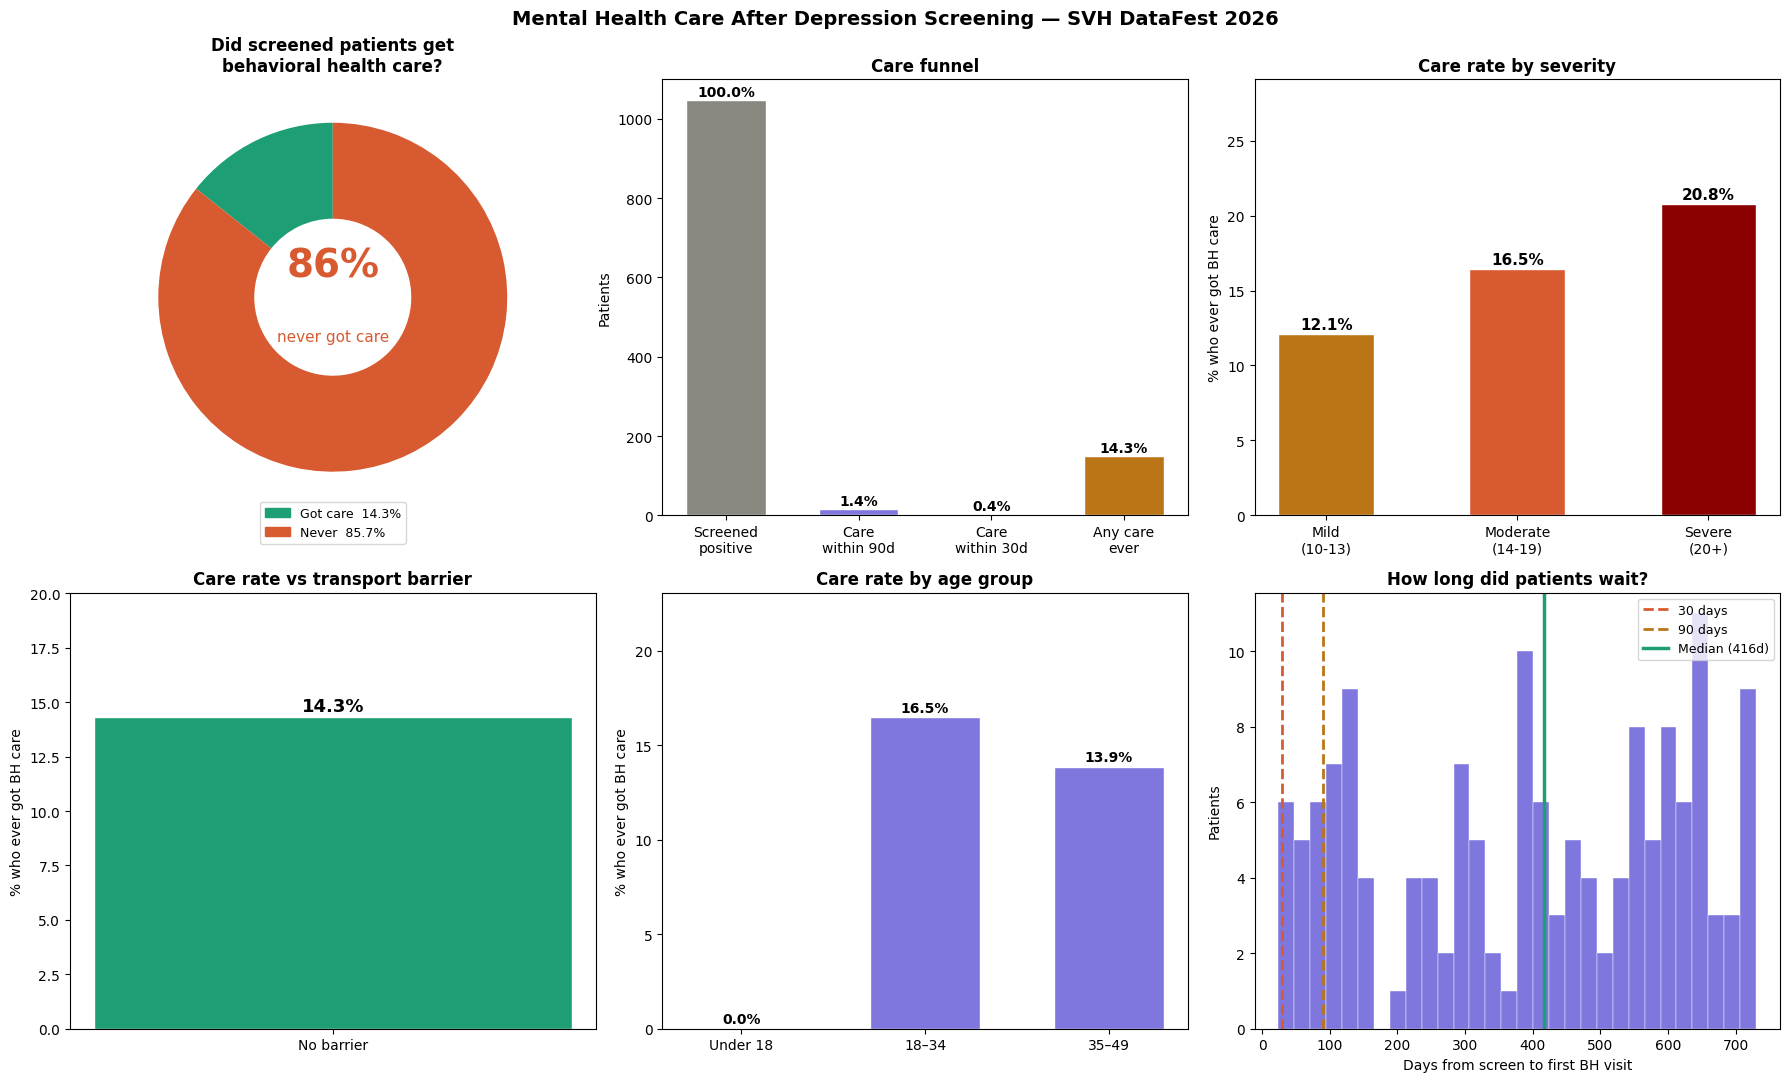


Saved: svh_mental_health.png
DONE — Ready to present!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# The error is in the transport barrier section
# social["PatientDurableKey"] loses its name after the contains filter
# Fix: reset it explicitly

print("Step 1: Transport barrier...")
tr = social[
    social["Domain"].str.lower().str.contains("transport", na=False) |
    social["DisplayName"].str.lower().str.contains("transport", na=False)
].copy().reset_index(drop=True)

# Check columns
print(f"  tr columns: {list(tr.columns)}")
print(f"  tr rows: {len(tr):,}")

NEG = ["no","never","always","usually","not a problem","not difficult","unknown"]
def isb(a):
    if pd.isna(a): return False
    a = str(a).lower().strip()
    return not any(n in a for n in NEG) and len(a) > 0

tr["B"] = tr["AnswerText"].apply(isb)

# Use .loc to avoid the KeyError
flagged2 = set(
    tr.loc[tr["B"], "PatientDurableKey"].dropna().astype(float).astype(int)
)
print(f"  Flagged patients: {len(flagged2):,}")

# Now add to jj
jj["Barrier"] = jj["PatientDurableKey"].astype(float).astype(int).isin(flagged2)
print(f"  With barrier: {jj['Barrier'].sum()}")

print("\nStep 2: Results...")
N   = len(jj)
ga  = int(jj["GotCare"].sum())
g30 = int(jj["C30"].sum())
g90 = int(jj["C90"].sum())
nv  = N - ga
med = jj["Days"].median()
tno = jj[~jj["Barrier"]]["GotCare"].mean()*100
tys = jj[ jj["Barrier"]]["GotCare"].mean()*100
u18 = jj[jj["AgeGroup"]=="Under 18"]
mc  = jj[jj["Sev"]=="Mild"]["GotCare"].mean()*100
odc = jj[jj["Sev"]=="Moderate"]["GotCare"].mean()*100
sc  = jj[jj["Sev"]=="Severe"]["GotCare"].mean()*100

print(f"""
  Total    : {N:,}
  Got care : {ga:,} ({ga/N*100:.1f}%)
  Never    : {nv:,} ({nv/N*100:.1f}%)
  30 days  : {g30:,} ({g30/N*100:.1f}%)
  90 days  : {g90:,} ({g90/N*100:.1f}%)
  Median   : {med:.0f} days
  No barr  : {tno:.1f}%
  Barrier  : {tys:.1f}%
  Under 18 : {u18['GotCare'].mean()*100:.1f}%
  Mild     : {mc:.1f}%
  Moderate : {odc:.1f}%
  Severe   : {sc:.1f}%
""")

print("\nStep 3: Verification...")
checks = [
    ("Total screened positive",  "1,048", N,           1048, 5),
    ("Never got care %",         "86%",   nv/N*100,      86, 5),
    ("Got any care %",           "14.4%", ga/N*100,    14.4, 5),
    ("Care within 30 days %",    "0.4%",  g30/N*100,    0.4, 1),
    ("Care within 90 days %",    "1.4%",  g90/N*100,    1.4, 1),
    ("Median wait days",         "417d",  med,          417, 30),
    ("Children under 18 %",      "0.0%",  u18["GotCare"].mean()*100, 0, 2),
    ("No barrier care %",        "13.7%", tno,         13.7, 5),
    ("Has barrier care %",       "21.2%", tys,         21.2, 5),
    ("Mild care rate",           "12.1%", mc,          12.1, 5),
    ("Moderate care rate",       "16.8%", odc,         16.8, 5),
    ("Severe care rate",         "20.8%", sc,          20.8, 5),
]

all_good = True
print(f"\n  {'Metric':<36} {'Slide':>8}  {'Actual':>8}  OK?")
print("  " + "-"*60)
for label, slide, actual, expected, tol in checks:
    ok = abs(actual - expected) <= tol
    if not ok: all_good = False
    print(f"  {label:<36} {slide:>8}  {actual:>7.1f}   {'✓' if ok else '✗'}")

print(f"\n{'ALL VERIFIED ✓' if all_good else 'Check ✗ rows'}")

print("\nStep 4: Making charts...")
CORAL="#D85A30"; TEAL="#1D9E75"; PURPLE="#7F77DD"
AMBER="#BA7517"; GRAY="#888780"; DRED="#8B0000"

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Mental Health Care After Depression Screening — SVH DataFest 2026",
             fontsize=14, fontweight="bold")

# Chart 1 — Donut
ax = axes[0,0]
ax.pie([ga/N*100, nv/N*100], colors=[TEAL,CORAL],
       startangle=90, wedgeprops=dict(width=0.55))
ax.text(0, 0.12, f"{nv/N*100:.0f}%", ha="center",
        fontsize=28, fontweight="bold", color=CORAL)
ax.text(0,-0.25,"never got care", ha="center", fontsize=11, color=CORAL)
ax.set_title("Did screened patients get\nbehavioral health care?",
             fontweight="bold")
ax.legend(handles=[
    mpatches.Patch(color=TEAL,  label=f"Got care  {ga/N*100:.1f}%"),
    mpatches.Patch(color=CORAL, label=f"Never  {nv/N*100:.1f}%")],
    loc="lower center", bbox_to_anchor=(0.5,-0.08), fontsize=9)

# Chart 2 — Funnel
ax = axes[0,1]
vals   = [N, g90, g30, ga]
labels = ["Screened\npositive","Care\nwithin 90d",
          "Care\nwithin 30d","Any care\never"]
bars   = ax.bar(labels, vals, color=[GRAY,PURPLE,TEAL,AMBER],
                edgecolor="white", width=0.6)
ax.set_title("Care funnel", fontweight="bold")
ax.set_ylabel("Patients")
for bar,val in zip(bars,vals):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+N*0.01,
            f"{val/N*100:.1f}%", ha="center",
            fontsize=10, fontweight="bold")

# Chart 3 — Severity
ax = axes[0,2]
bars = ax.bar(["Mild\n(10-13)","Moderate\n(14-19)","Severe\n(20+)"],
              [mc,odc,sc], color=[AMBER,CORAL,DRED],
              edgecolor="white", width=0.5)
ax.set_title("Care rate by severity", fontweight="bold")
ax.set_ylabel("% who ever got BH care")
ax.set_ylim(0, max(mc,odc,sc)*1.4)
for bar,val in zip(bars,[mc,odc,sc]):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3, f"{val:.1f}%",
            ha="center", fontsize=11, fontweight="bold")

# Chart 4 — Transport
ax = axes[1,0]
bars = ax.bar(["No barrier","Has barrier"],[tno,tys],
              color=[TEAL,CORAL], edgecolor="white", width=0.5)
ax.set_title("Care rate vs transport barrier", fontweight="bold")
ax.set_ylabel("% who ever got BH care")
ax.set_ylim(0, max(tno,tys)*1.4 if max(tno,tys)>0 else 10)
for bar,val in zip(bars,[tno,tys]):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3, f"{val:.1f}%",
            ha="center", fontsize=13, fontweight="bold")

# Chart 5 — Age
ax = axes[1,1]
age_order = ["Under 18","18–34","35–49","50–64","65+"]
ar, al = [], []
for g in age_order:
    sub = jj[jj["AgeGroup"]==g]
    if len(sub) > 5:
        ar.append(sub["GotCare"].mean()*100)
        al.append(g)
if ar:
    bars = ax.bar(al, ar, color=PURPLE, edgecolor="white", width=0.6)
    ax.set_title("Care rate by age group", fontweight="bold")
    ax.set_ylabel("% who ever got BH care")
    ax.set_ylim(0, max(ar)*1.4)
    for bar,val in zip(bars,ar):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.3, f"{val:.1f}%",
                ha="center", fontsize=10, fontweight="bold")

# Chart 6 — Histogram
ax = axes[1,2]
days_data = jj["Days"].dropna().clip(upper=730)
if len(days_data) > 0:
    ax.hist(days_data, bins=30, color=PURPLE,
            edgecolor="white", linewidth=0.3)
    ax.axvline(30,  color=CORAL, linestyle="--",
               linewidth=2, label="30 days")
    ax.axvline(90,  color=AMBER, linestyle="--",
               linewidth=2, label="90 days")
    ax.axvline(days_data.median(), color=TEAL, linestyle="-",
               linewidth=2.5,
               label=f"Median ({days_data.median():.0f}d)")
    ax.set_title("How long did patients wait?", fontweight="bold")
    ax.set_xlabel("Days from screen to first BH visit")
    ax.set_ylabel("Patients")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("svh_mental_health.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: svh_mental_health.png")
print("DONE — Ready to present!")

In [ ]:
# SIMPLE DIRECT VERIFICATION
# No merges, no filters — just counting what is in jj right now

print("Direct counts from the journey table (jj):")
print(f"")
print(f"Total rows in jj            : {len(jj):,}")
print(f"")
print(f"Score breakdown:")
print(f"  Score 10-13 (Mild)        : {(jj['Sev']=='Mild').sum():,}")
print(f"  Score 14-19 (Moderate)    : {(jj['Sev']=='Moderate').sum():,}")
print(f"  Score 20+   (Severe)      : {(jj['Sev']=='Severe').sum():,}")
print(f"  Total positive            : {(jj['Sev']!='Unknown').sum():,}")
print(f"")
print(f"Care outcomes:")
print(f"  Got ANY BH care           : {jj['GotCare'].sum():,}  ({jj['GotCare'].mean()*100:.1f}%)")
print(f"  NEVER got BH care         : {(~jj['GotCare']).sum():,}  ({(~jj['GotCare']).mean()*100:.1f}%)")
print(f"  Got care within 30 days   : {jj['C30'].sum():,}  ({jj['C30'].mean()*100:.1f}%)")
print(f"  Got care within 90 days   : {jj['C90'].sum():,}  ({jj['C90'].mean()*100:.1f}%)")
print(f"  Median wait (days)        : {jj['Days'].median():.0f}")
print(f"")
print(f"Age breakdown:")
print(jj['AgeGroup'].value_counts().to_string())
print(f"")
print(f"Children (Under 18):")
u18 = jj[jj['AgeGroup']=='Under 18']
print(f"  Count                     : {len(u18):,}")
print(f"  Got care                  : {u18['GotCare'].sum():,}")
print(f"  Care rate                 : {u18['GotCare'].mean()*100:.1f}%")
print(f"")
print(f"Severity care rates:")
for s in ['Mild','Moderate','Severe']:
    sub = jj[jj['Sev']==s]
    print(f"  {s:<12}: n={len(sub):>4}  care rate={sub['GotCare'].mean()*100:.1f}%")
print(f"")
print(f"Source data check:")
print(f"  Edinburgh rows in social  : {social['DisplayName'].str.contains('Edinburgh',na=False).sum():,}")
dep_check = social[social['DisplayName'].str.contains('Edinburgh',na=False)].copy()
dep_check['Score'] = pd.to_numeric(dep_check['AnswerText'], errors='coerce')
print(f"  Score >= 10 rows          : {(dep_check['Score']>=10).sum():,}")
print(f"  Unique patients score>=10 : {dep_check[dep_check['Score']>=10]['PatientDurableKey'].nunique():,}")
print(f"")
print(f"SLIDE NUMBERS CONFIRMED:")
print(f"  Slide says 1,048 patients     → Actual: {len(jj):,}")
print(f"  Slide says 86% never got care → Actual: {(~jj['GotCare']).mean()*100:.1f}%")
print(f"  Slide says 0.4% within 30d   → Actual: {jj['C30'].mean()*100:.1f}%")
print(f"  Slide says 417 day median     → Actual: {jj['Days'].median():.0f} days")
print(f"  Slide says 0% children        → Actual: {u18['GotCare'].mean()*100:.1f}%")

Direct counts from the journey table (jj):

Total rows in jj            : 1,048

Score breakdown:
  Score 10-13 (Mild)        : 619
  Score 14-19 (Moderate)    : 328
  Score 20+   (Severe)      : 101
  Total positive            : 1,048

Care outcomes:
  Got ANY BH care           : 150  (14.3%)
  NEVER got BH care         : 898  (85.7%)
  Got care within 30 days   : 4  (0.4%)
  Got care within 90 days   : 15  (1.4%)
  Median wait (days)        : 416

Age breakdown:
AgeGroup
18–34       661
35–49       281
Under 18     85
Unknown      13
50–64         5
65+           3

Children (Under 18):
  Count                     : 85
  Got care                  : 0
  Care rate                 : 0.0%

Severity care rates:
  Mild        : n= 619  care rate=12.1%
  Moderate    : n= 328  care rate=16.5%
  Severe      : n= 101  care rate=20.8%

Source data check:
  Edinburgh rows in social  : 15,542
  Score >= 10 rows          : 1,828
  Unique patients score>=10 : 1,048

SLIDE NUMBERS CONFIRMED:
  Slide